In [1035]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from typing import Dict


# from playground.configs.generate_aspect_ratios import param_cou nter

In [494]:
def param_counter(
    num_layers: int,
    hidden_size: int,
    ffn_hidden_size: int | None = None,
    ffn_mult: float = 4.0,
    swiglu: bool = True,
    tied_embeddings: bool = True,
    vocab_size: int = 50304,
    attn_residual: bool = False,
    attn_res_learnable_norm: bool = False
) -> Dict[str, int]:
    h = hidden_size
    f = ffn_hidden_size if ffn_hidden_size is not None else int(ffn_mult * h)

    attn_params = 4 * h * h                    # W_q, W_k, W_v, W_o  (MHA, no bias)
    ffn_params = (2 + int(swiglu)) * h * f     # up, down (+ gate if SwiGLU)
    norm_params = 2 * h                        # 2 x RMSNorm per layer

    per_layer_params = attn_params + ffn_params + norm_params

    hidden_params = num_layers * per_layer_params
    embed_params = (2 - int(tied_embeddings)) * vocab_size * h
    final_norm_params = h                      # pre-head RMSNorm

    attn_res_params = attn_res_norm_params = 0
    if attn_residual:    
        attn_res_norm_params = (num_layers * 2 * h + h) if attn_res_learnable_norm else 0
        attn_res_params = 2 * num_layers * h

    hidden_params += attn_res_params + attn_res_norm_params

    return {
        "hidden_params": hidden_params,
        "embed_params": embed_params,
        "final_norm_params": final_norm_params,
        "total_params": hidden_params + embed_params + final_norm_params,
    }

$N_{\text{total}} = 16 \cdot H^2 \cdot L + (2 \cdot L + 2 \cdot V + 1) \cdot H$

and with Attention Residuals,

$N_{\text{total}} = 16 \cdot H^2 \cdot L + (2 \cdot L + 2 \cdot V + 1) \cdot H + 2 \cdot L \cdot H$

and with Attention Residuals with learnable norms,

$N_{\text{total}} = 16 \cdot H^2 \cdot L + (2 \cdot L + 2 \cdot V + 1) \cdot H + 2 \cdot L \cdot H + 2 \cdot L \cdot H + H$ 

$\Rightarrow N_{\text{total}} = L \cdot 16H^2 + 2 \cdot (3 \cdot L + V + 1) \cdot H$

for the non-attention-residual variant,

now, $dN = \frac{\partial N}{\partial L} \cdot dL + \frac{\partial N}{\partial H} \cdot dH$

substituting from $N_{\text{total}}$, for $dN=0$ we get,

$\frac{dL}{dH} = \left( -\frac{32 \cdot H \cdot L + 2 \cdot L + 2 \cdot V + 1}{16 \cdot H^2 + 2 \cdot H} \right)$

approximating terms,

$\frac{dL}{dH} = - \left( \frac{32 \cdot H \cdot L + 2 \cdot V}{16 \cdot H^2} \right) = -\frac{2 \cdot L}{H} - \frac{V}{8 \cdot H^2}$

ignoring the vocab term,

$\frac{dL}{dH} = -2 \frac{L}{H} \Rightarrow \frac{dL}{L} = -2\frac{dH}{H} $

integrating,

$\Rightarrow ln(L) = -2 \cdot ln(H) + constant$

$\Rightarrow L \cdot H^2 = constant$

Text(0.5, 1.0, 'RL=20, H=1536 [900 M]')

<Figure size 640x480 with 0 Axes>

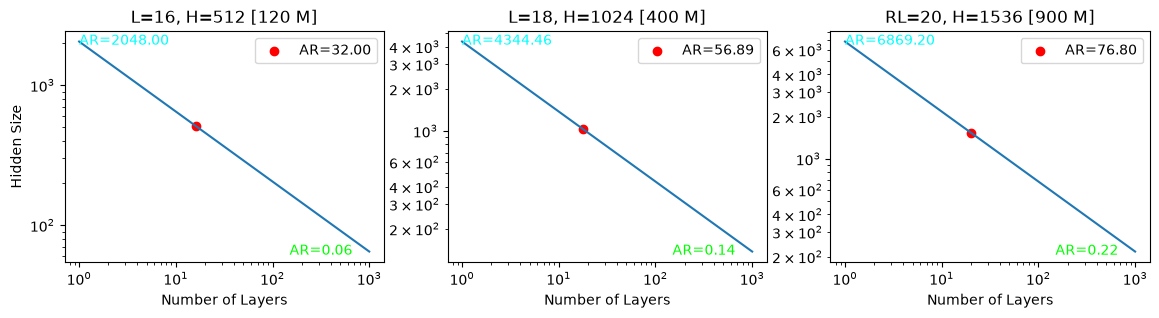

In [552]:
plt.clf()

fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ref_L = 16
ref_H = 512
const = ref_L * ref_H ** 2

L = np.arange(1, 1000, 1)
H = np.sqrt(const / L)

ax[0].plot(L, H)
ax[0].scatter(ref_L, ref_H, color="red", label=f"AR={ref_H/ref_L:.2f}")
ax[0].text(min(L), max(H) * 0.95, f"AR={max(H)/min(L):.2f}", fontsize=10, color="cyan")
ax[0].text(max(L) * 0.15, min(H) * 0.95, f"AR={min(H)/max(L):.2f}", fontsize=10, color="lime")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Number of Layers")
ax[0].set_ylabel("Hidden Size")
ax[0].legend()
ax[0].set_title("L=16, H=512 [120 M]")


ref_L = 18
ref_H = 1024
const = ref_L * ref_H ** 2

L = np.arange(1, 1000, 1)
H = np.sqrt(const / L)

ax[1].plot(L, H)
ax[1].scatter(ref_L, ref_H, color="red", label=f"AR={ref_H/ref_L:.2f}")
ax[1].text(min(L), max(H) * 0.95, f"AR={max(H)/min(L):.2f}", fontsize=10, color="cyan")
ax[1].text(max(L) * 0.15, min(H) * 0.95, f"AR={min(H)/max(L):.2f}", fontsize=10, color="lime")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Number of Layers")
ax[1].legend()
ax[1].set_title("L=18, H=1024 [400 M]")


ref_L = 20
ref_H = 1536
const = ref_L * ref_H ** 2

L = np.arange(1, 1000, 1)
H = np.sqrt(const / L)

ax[2].plot(L, H)
ax[2].scatter(ref_L, ref_H, color="red", label=f"AR={ref_H/ref_L:.2f}")
ax[2].text(min(L), max(H) * 0.95, f"AR={max(H)/min(L):.2f}", fontsize=10, color="cyan")
ax[2].text(max(L) * 0.15, min(H) * 0.95, f"AR={min(H)/max(L):.2f}", fontsize=10, color="lime")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("Number of Layers")
ax[2].legend()
ax[2].set_title("RL=20, H=1536 [900 M]")

the same relationshop broadly holds for attention residuals, under the assumption that in,

$\frac{dL}{dH} = -\frac{2L}{H} - \frac{3\cdot L + V}{8 \cdot H^2} $,

the vocab-layer term is ignored.

Rearranging for $L(N, H)$,

Vanilla:

$L(N, H) = \frac{N - (2 \cdot V + 1)\cdot H}{16\cdot H^2 + 2 \cdot H}$

Attention Residuals (with trainable norms):

$L(N, H) = \frac{N - (2 \cdot V + 1)\cdot H}{16\cdot H^2 + 6 \cdot H}$

For simplicity, assume $L > 0$ and solve,


$H < \frac{N}{2\cdot V + 1} \Rightarrow$ `Maximum Width`

NOTE, embed parameters are $\propto H$, and tracking the contribution of embed parameters with growing width is important.

Also, let $\rho = \frac{H}{L}$, be the aspect ratio. 

Substituting $L = \frac{\rho}{H}$ in $N_{\text{total}}$, we get, 

$\rho(N, H) = \frac{16 \cdot H^3 + 6 \cdot H^2}{N - (2 \cdot V + 1) \cdot H} \Rightarrow \rho \propto H^3$

<Figure size 640x480 with 0 Axes>

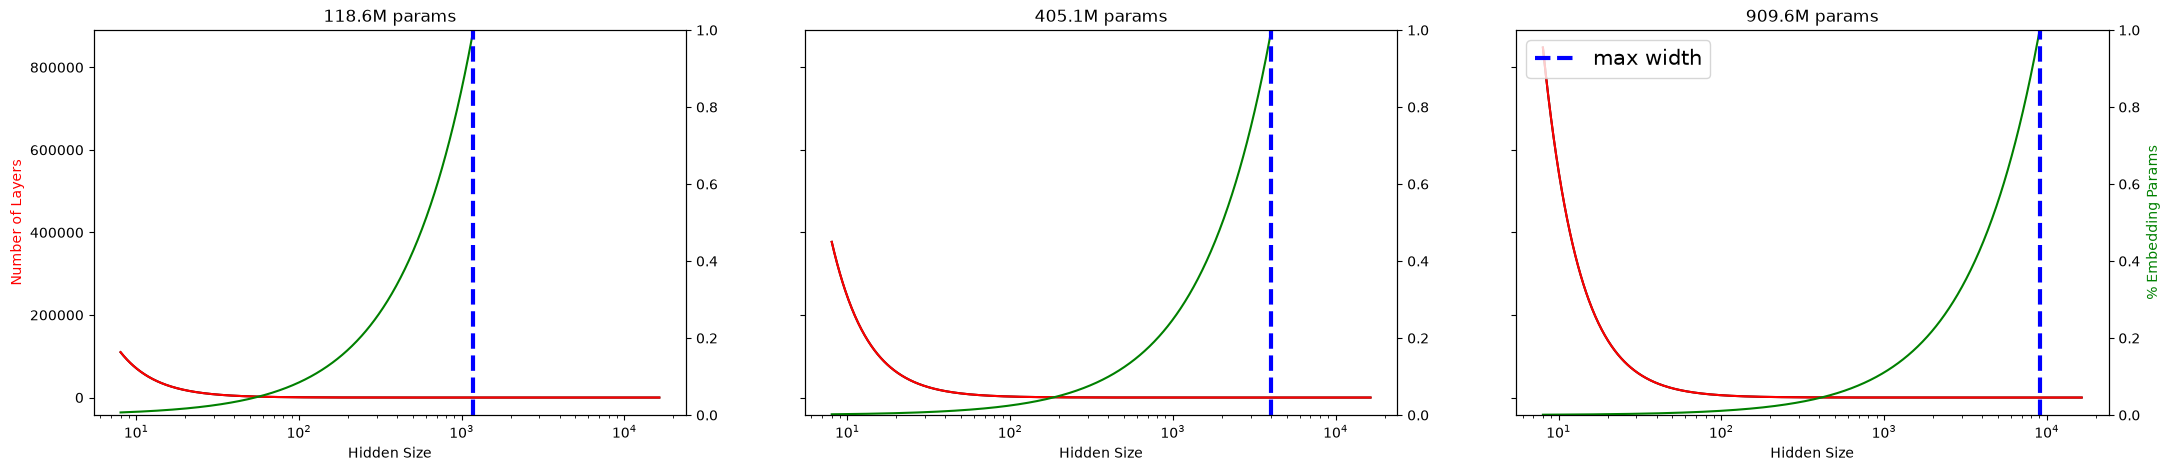

In [726]:
L_estimated = lambda N, H, V=50304: (N - ((2 * V + 1) * H)) / (16 * H ** 2 + 6 * H)
vocab_size = 50304
H_hidden = 2 ** np.linspace(np.log2(8), np.log2(16384), 1000)

plt.clf()

fig, ax = plt.subplots(1, 3, figsize=(26, 5), sharey=True)

# 100 M model
N_vanilla = param_counter(
    16, 512, 2048, tied_embeddings=False
)
N_attnres = param_counter(
    16, 512, 2048, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[0].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[0].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[0].set_xscale("log")
ax[0].set_xlabel("Hidden Size")
ax[0].set_ylabel("Number of Layers", color="red")
ax[0].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[0].set_yscale("log")
_ax = ax[0].twinx()
_ax.plot(
    H_hidden,
    [(2 * vocab_size * _h) / N_vanilla["total_params"] for _h in H_hidden],
    color="green"
)
_ax.set_ylim(0, 1.0)
_ax.vlines(
    x=N_vanilla["total_params"] / (2 * vocab_size + 1),
    ymin=0,
    ymax=1,
    color="blue",
    linestyle="--",
    linewidth=3,
)



# 400 M model
N_vanilla = param_counter(
    18, 1024, 4096, tied_embeddings=False
)
N_attnres = param_counter(
    18, 1024, 4096, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[1].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[1].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[1].set_xscale("log")
ax[1].set_xlabel("Hidden Size")
# ax[1].set_ylabel("Number of Layers")
ax[1].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[1].set_yscale("log")
_ax = ax[1].twinx()
_ax.plot(
    H_hidden,
    [(2 * vocab_size * _h) / N_vanilla["total_params"] for _h in H_hidden],
    color="green"
)
_ax.set_ylim(0, 1.0)
_ax.vlines(
    x=N_vanilla["total_params"] / (2 * vocab_size + 1),
    ymin=0,
    ymax=1,
    color="blue",
    linestyle="--",
    linewidth=3,
)



# 900 M model
N_vanilla = param_counter(
    20, 1536, 6144, tied_embeddings=False
)
N_attnres = param_counter(
    20, 1536, 6144, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[2].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[2].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[2].set_xscale("log")
ax[2].set_xlabel("Hidden Size")
# ax[2].set_ylabel("Number of Layers")
ax[2].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[2].set_yscale("log")
# ax[2].set_ylim(2, 10e6)
_ax = ax[2].twinx()
_ax.plot(
    H_hidden,
    [(2 * vocab_size * _h) / N_vanilla["total_params"] for _h in H_hidden],
    color="green"
)
_ax.set_ylabel("% Embedding Params", color="green")
_ax.set_ylim(0, 1.0)
_ax.vlines(
    x=N_vanilla["total_params"] / (2 * vocab_size + 1),
    ymin=0,
    ymax=1,
    color="blue",
    linestyle="--",
    linewidth=3,
    label="max width"
)
_ax.legend(fontsize=15, loc="upper left")

/tmp/ipykernel_78565/1662812332.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _ax.legend(fontsize=15, loc="upper left")


<Figure size 640x480 with 0 Axes>

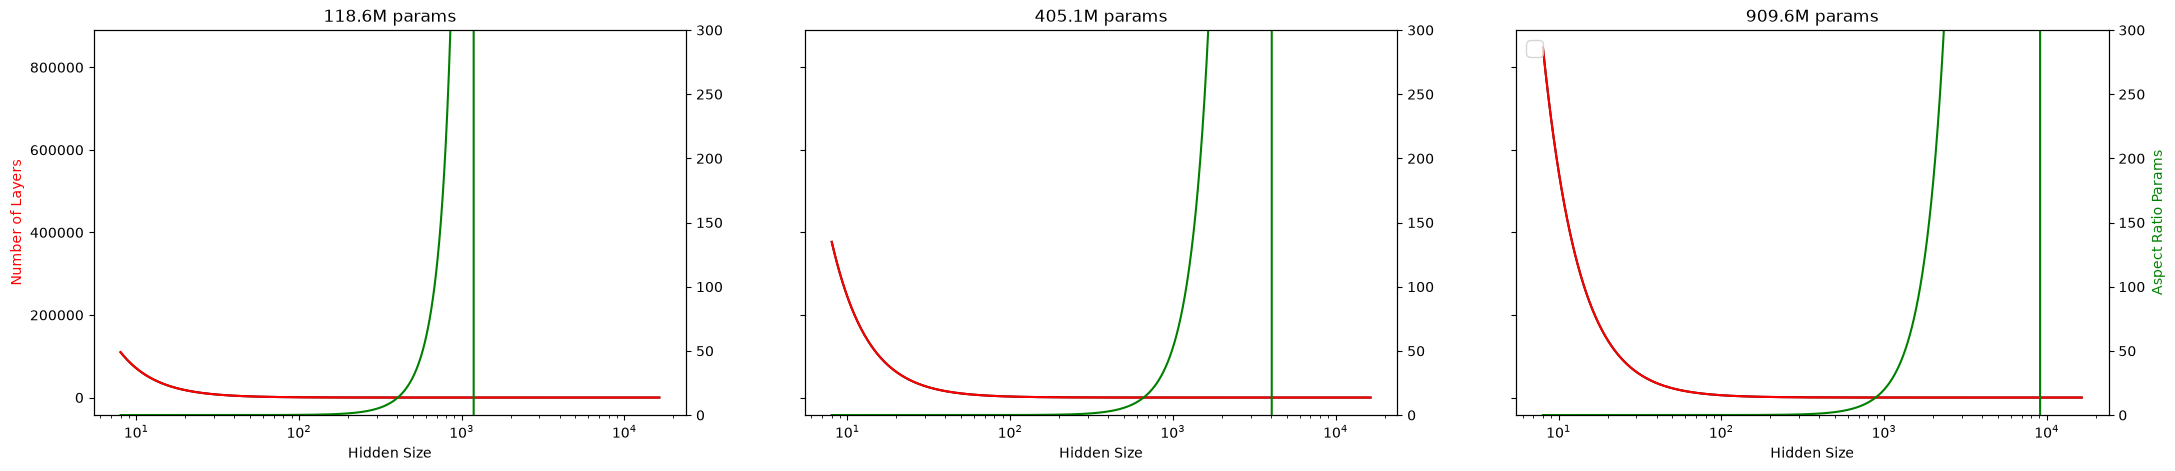

In [734]:
L_estimated = lambda N, H, V=50304: (N - ((2 * V + 1) * H)) / (16 * H ** 2 + 6 * H)
rho_estimated = lambda N, H, V=50304: (16 * H **3 + 6 * H ** 2) / (N - ((2 * V + 1) * H))
vocab_size = 50304
H_hidden = 2 ** np.linspace(np.log2(8), np.log2(16384), 1000)

plt.clf()

fig, ax = plt.subplots(1, 3, figsize=(26, 5), sharey=True)

# 100 M model
N_vanilla = param_counter(
    16, 512, 2048, tied_embeddings=False
)
N_attnres = param_counter(
    16, 512, 2048, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[0].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[0].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[0].set_xscale("log")
ax[0].set_xlabel("Hidden Size")
ax[0].set_ylabel("Number of Layers", color="red")
ax[0].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[0].set_yscale("log")
_ax = ax[0].twinx()
_ax.plot(
    H_hidden,
    [rho_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="green"
)
_ax.set_ylim(0, 300)
# _ax.vlines(
#     x=N_vanilla["total_params"] / (2 * vocab_size + 1),
#     ymin=0,
#     ymax=1,
#     color="blue",
#     linestyle="--",
#     linewidth=3,
# )



# 400 M model
N_vanilla = param_counter(
    18, 1024, 4096, tied_embeddings=False
)
N_attnres = param_counter(
    18, 1024, 4096, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[1].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[1].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[1].set_xscale("log")
ax[1].set_xlabel("Hidden Size")
# ax[1].set_ylabel("Number of Layers")
ax[1].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[1].set_yscale("log")
_ax = ax[1].twinx()
_ax.plot(
    H_hidden,
    [rho_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="green"
)
_ax.set_ylim(0, 300)
# _ax.vlines(
#     x=N_vanilla["total_params"] / (2 * vocab_size + 1),
#     ymin=0,
#     ymax=1,
#     color="blue",
#     linestyle="--",
#     linewidth=3,
# )



# 900 M model
N_vanilla = param_counter(
    20, 1536, 6144, tied_embeddings=False
)
N_attnres = param_counter(
    20, 1536, 6144, tied_embeddings=False, attn_residual=True, attn_res_learnable_norm=True
)
ax[2].plot(
    H_hidden, 
    [L_estimated(N_vanilla["total_params"], _h) for _h in H_hidden],
    color="black"
)
ax[2].plot(
    H_hidden, 
    [L_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="red"
)
ax[2].set_xscale("log")
ax[2].set_xlabel("Hidden Size")
# ax[2].set_ylabel("Number of Layers")
ax[2].set_title(f"{N_vanilla["total_params"] / 1e6:.1f}M params")
# ax[2].set_yscale("log")
# ax[2].set_ylim(2, 10e6)
_ax = ax[2].twinx()
_ax.plot(
    H_hidden,
    [rho_estimated(N_attnres["total_params"], _h) for _h in H_hidden],
    color="green"
)
_ax.set_ylabel("Aspect Ratio Params", color="green")
_ax.set_ylim(0, 300)
# _ax.vlines(
#     x=N_vanilla["total_params"] / (2 * vocab_size + 1),
#     ymin=0,
#     ymax=1,
#     color="blue",
#     linestyle="--",
#     linewidth=3,
#     label="max width"
# )
_ax.legend(fontsize=15, loc="upper left")

Therefore, given a param count $N$ and a vocab size $V$, we can derive a maximum width limit: $H_{\text{max}} = \frac{N}{2 \cdot V + 1}$

Let us choose a minimum layer we want as $L_{\text{min}}=2$ and an $H_{\text{min}}=8$ (ideally, this is some $k \times$ the _#Attention Heads_)

**Goal**: Cover the space of $L$ and $\rho$, given $N$, $V$, and $[H_{\text{min}}, H_{\text{max}}]$

We know,

$L \propto \frac{1}{H^2}$ and $\rho \propto H^3$

We rewrite to have,

$16 \cdot H^3 + 6 \cdot H^2 + (2V+1) \cdot \rho \cdot H - N \cdot \rho = 0$




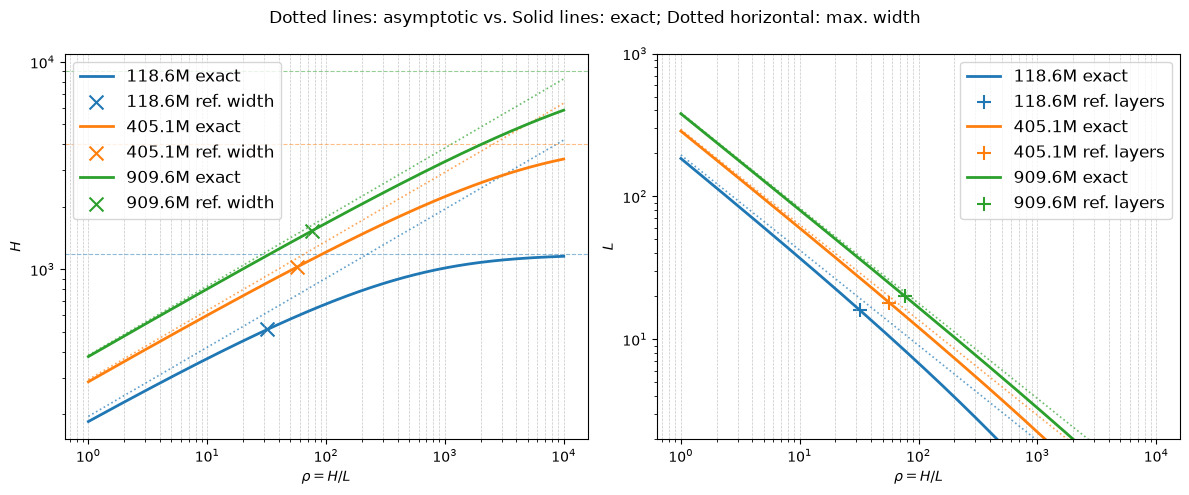

In [759]:
V = 50304
c = 2 * V + 1                      # untied embeddings + final norm
configs = {"118.6M": 118.6e6, "405.1M": 405.1e6, "909.6M": 909.6e6}
H_map = {"118.6M": 512, "405.1M": 1024, "909.6M": 1536}
L_map = {"118.6M": 16, "405.1M": 18, "909.6M": 20}

def H_exact(rho, N):
    """Real positive root of 16H^3 + 2H^2 + c*rho*H - N*rho = 0."""
    out = np.empty_like(rho, dtype=float)
    for i, r in enumerate(np.atleast_1d(rho)):
        roots = np.roots([16.0, 6.0, c * r, -N * r])
        real = roots[np.abs(roots.imag) < 1e-9].real
        out[i] = real[real > 0].max()
    return out

def H_asym(rho, N):
    return (N * rho / 16.0) ** (1 / 3)

rho = np.logspace(0, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for (label, N), col in zip(configs.items(), ["C0", "C1", "C2"]):
    He, Ha = H_exact(rho, N), H_asym(rho, N)

    axes[0].loglog(rho, He, col, lw=2, label=f"{label} exact")
    axes[0].loglog(rho, Ha, col, ls=":", lw=1.2, alpha=0.7)
    axes[0].axhline(N / c, color=col, ls="--", lw=0.8, alpha=0.5)
    axes[0].scatter(H_map[label] / L_map[label], H_map[label], color=col, marker="x", s=100, label=f"{label} ref. width")

    axes[1].loglog(rho, He / rho, col, lw=2, label=f"{label} exact")
    axes[1].loglog(rho, Ha / rho, col, ls=":", lw=1.2, alpha=0.7)
    axes[1].scatter(H_map[label] / L_map[label], L_map[label], color=col, marker="+", s=100, label=f"{label} ref. layers")

axes[1].axhline(1, color="k", ls="-", lw=0.8, alpha=0.4)

axes[0].set_ylabel(r"$H$")
axes[1].set_ylabel(r"$L$")
for a in axes:
    a.set_xlabel(r"$\rho = H/L$")
    a.legend(fontsize=12)

# axes[0].set_xlim(1, 200)
# axes[1].set_xlim(1, 200)
axes[1].set_ylim(2, 1000)

# adding vertical grid lines for the x-axis 
axes[0].grid(axis='x', which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].grid(axis='x', which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.suptitle("Dotted lines: asymptotic vs. Solid lines: exact; Dotted horizontal: max. width")

plt.tight_layout()
plt.show()

Now for practical purposes, what we have and need:

* $H_{\text{min}} \rightarrow$ defined as $min(\#heads) \times min(per\_head\_dim)$ 
* $H_{\text{max}} \rightarrow$ derived as a function of $(N, V)$
* $L_{\text{min}} \rightarrow$ defined as per problem specification, e.g. $2$
* $L_{\text{max}} \rightarrow$ derived as $L(H_{\text{min}})$
* $\therefore$
* $\rho_{\text{min}} \rightarrow \frac{H_{\text{min}}}{L(H_{\text{min}})} \Rightarrow$ defined explicitly
* $\rho_{\text{max}} \rightarrow \frac{L^{-1}(L_{\text{min}})}{L_{\text{min}}} \Rightarrow$ defined explicitly

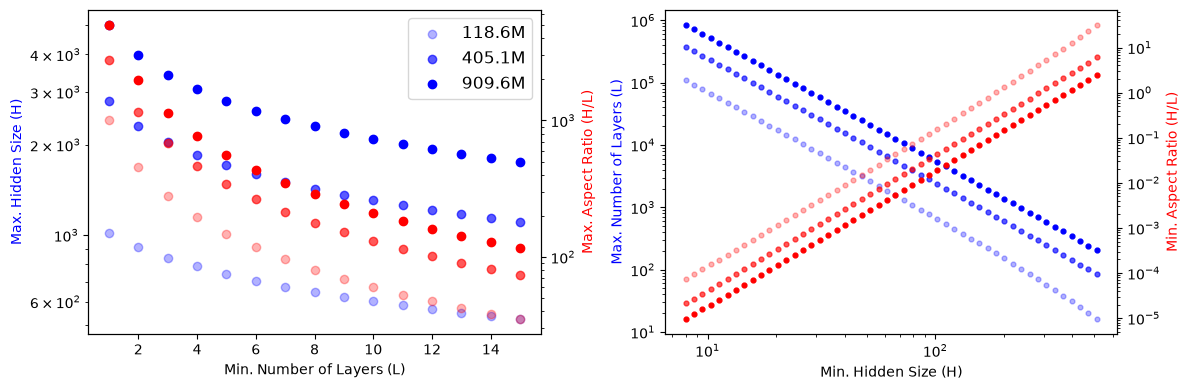

In [791]:
V = 50304
Ns = [118.6e6, 405.1e6, 909.6e6]
alphas = np.linspace(0.3, 1.0, len(Ns))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax0, ax1 = axes[0].twinx(), axes[1].twinx()

L_mins = np.arange(1, 16, 1)

for N, a in zip(Ns, alphas):
    # --- left: choose L_min -> H_max, rho_max ---
    H_max = np.array([max(np.roots([16*Lm, 2*V + 1 + 6*Lm, -N])) for Lm in L_mins])
    axes[0].scatter(L_mins, H_max, color="blue", alpha=a, label=f"{N/1e6:.1f}M")
    ax0.scatter(L_mins, H_max / L_mins, color="red", alpha=a)

    # --- right: choose H_min -> L_max, rho_min ---
    H_hi = min(512, 0.95 * N / (2*V + 1))
    H_mins = 2**np.linspace(np.log2(8), np.log2(H_hi), 50)
    L_max = (N - (2*V + 1) * H_mins) / (16 * H_mins**2 + 6 * H_mins)
    axes[1].scatter(H_mins, L_max, color="blue", s=12, alpha=a)
    ax1.scatter(H_mins, H_mins / L_max, color="red", s=12, alpha=a)

axes[0].set_xlabel("Min. Number of Layers (L)")
axes[0].set_ylabel("Max. Hidden Size (H)", color="blue")
axes[0].set_yscale("log")
axes[0].legend(fontsize=12, loc="upper right")
ax0.set_ylabel("Max. Aspect Ratio (H/L)", color="red")
ax0.set_yscale("log")

axes[1].set_xlabel("Min. Hidden Size (H)")
axes[1].set_ylabel("Max. Number of Layers (L)", color="blue")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
ax1.set_ylabel("Min. Aspect Ratio (H/L)", color="red")
ax1.set_yscale("log")

plt.tight_layout()
plt.show()

In [1086]:
rho_min = lambda N, H_min, V=50304:(16 * H_min ** 3 + 6 * H_min ** 2) / (N - ((2 * V + 1) * H_min))
L_inv = lambda N, L_min, V=50304: max([r.real for r in np.roots([16 * L_min, 2 * V + 1 + 6 * L_min, -N])])
rho_max = lambda N, L_min, V=50304: L_inv(N, L_min, V) / L_min
L_derived = lambda N, H, V=50304: (N - ((2 * V + 1) * H)) / (16 * H ** 2 + 6 * H)

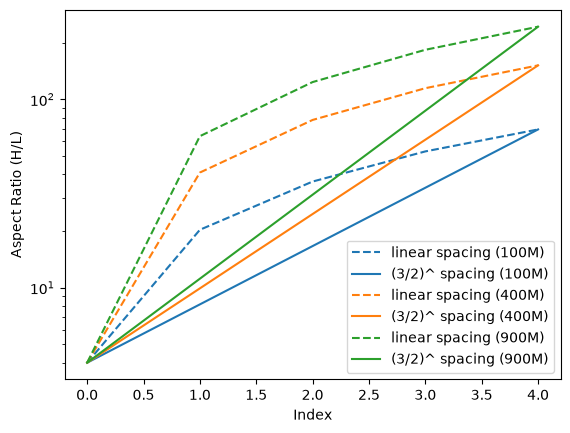

In [ ]:
import math

_L_max = 100
L_min = 9
H_min = 64
_min_rho = 10

num_ratios = 5

plt.clf()

colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
for i, _path in enumerate(sorted(Path("/u/nmallik/projects/git_repos/MegatronScaling/playground/configs/model_size/ladder/").glob("*.info"))):
    with open(_path, "r") as f:
        data = {line.strip().split("=")[0].lower(): int(line.strip().split("=")[1]) for line in f.readlines()}
    _params = param_counter(
        data["num_layers"],
        data["hidden_size"],
        data["ffn_hidden_size"],
        tied_embeddings=False,
        attn_residual=True,
        attn_res_learnable_norm=True
    )
    N_embed = _params["embed_params"]
    N = _params["total_params"]

    r_min = max(rho_min(N, H_min), _min_rho)
    r_max = rho_max(N, L_min)

    _spacing= np.linspace(r_min, r_max, num_ratios)
    _spacing1 = np.exp(np.linspace(np.log(r_min), np.log(r_max), num_ratios))
    _spacing2 = 2 ** np.linspace(np.log2(r_min), np.log2(r_max), num_ratios)
    _spacing3 = 3 ** np.linspace(math.log(r_min, 3), math.log(r_max, 3), num_ratios)
    _spacing4 = (3/2) ** np.linspace(math.log(r_min, 3/2), math.log(r_max, 3/2), num_ratios)
    _spacing5 = (10) ** np.linspace(math.log(r_min, 10), math.log(r_max, 10), num_ratios)
    _spacing6 = np.geomspace(r_min, r_max, num_ratios)

    plt.plot(_spacing, label=f"linear spacing ({_path.stem.split("_AR")[0]})", color=colors[i], linestyle="--")
    # plt.plot(_spacing1, label=f"exp spacing ({_path.stem})", color=colors[i], )
    # plt.plot(_spacing2, label=f"2^ spacing ({_path.stem})", color=colors[i], )
    # plt.plot(_spacing3, label=f"3^ spacing ({_path.stem})", color=colors[i], )
    plt.plot(_spacing4, label=f"(3/2)^ spacing ({_path.stem.split("_AR")[0]})", color=colors[i])
    # plt.plot(_spacing5, label=f"10^ spacing ({_path.stem})", color=colors[i], )
    # plt.plot(_spacing6, label=f"geom. spacing ({_path.stem})", color=colors[i], )

    plt.yscale("log")
    plt.ylabel("Aspect Ratio (H/L)")
    plt.xlabel("Index")
    plt.legend()
